In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('../data/Supplementary_Data_3_VFC_metadata.xlsx', usecols=['VFC','VC_size','perc_prevalence','median_perc_abun','primary_host_phylum'])

### Supplementary Fig. 18: VFC prevalence vs. median abundance in SPMP cohort, color-coded by host phylum

C:\Users\chenhr\AppData\Local\Temp\ipykernel_40480\2347513195.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['primary_host_phylum'] = df1['primary_host_phylum'].fillna('Unknown')
C:\Users\chenhr\AppData\Local\Temp\ipykernel_40480\2347513195.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['primary_host_phylum'] = np.where(df1.primary_host_phylum.isin(['Verrucomicrobiota','Methanobacteriota','Fusobacteriota']), 'Others', df1.primary_host_phylum)
c:\Users\chenhr\AppData\Local\Programs\Python\P

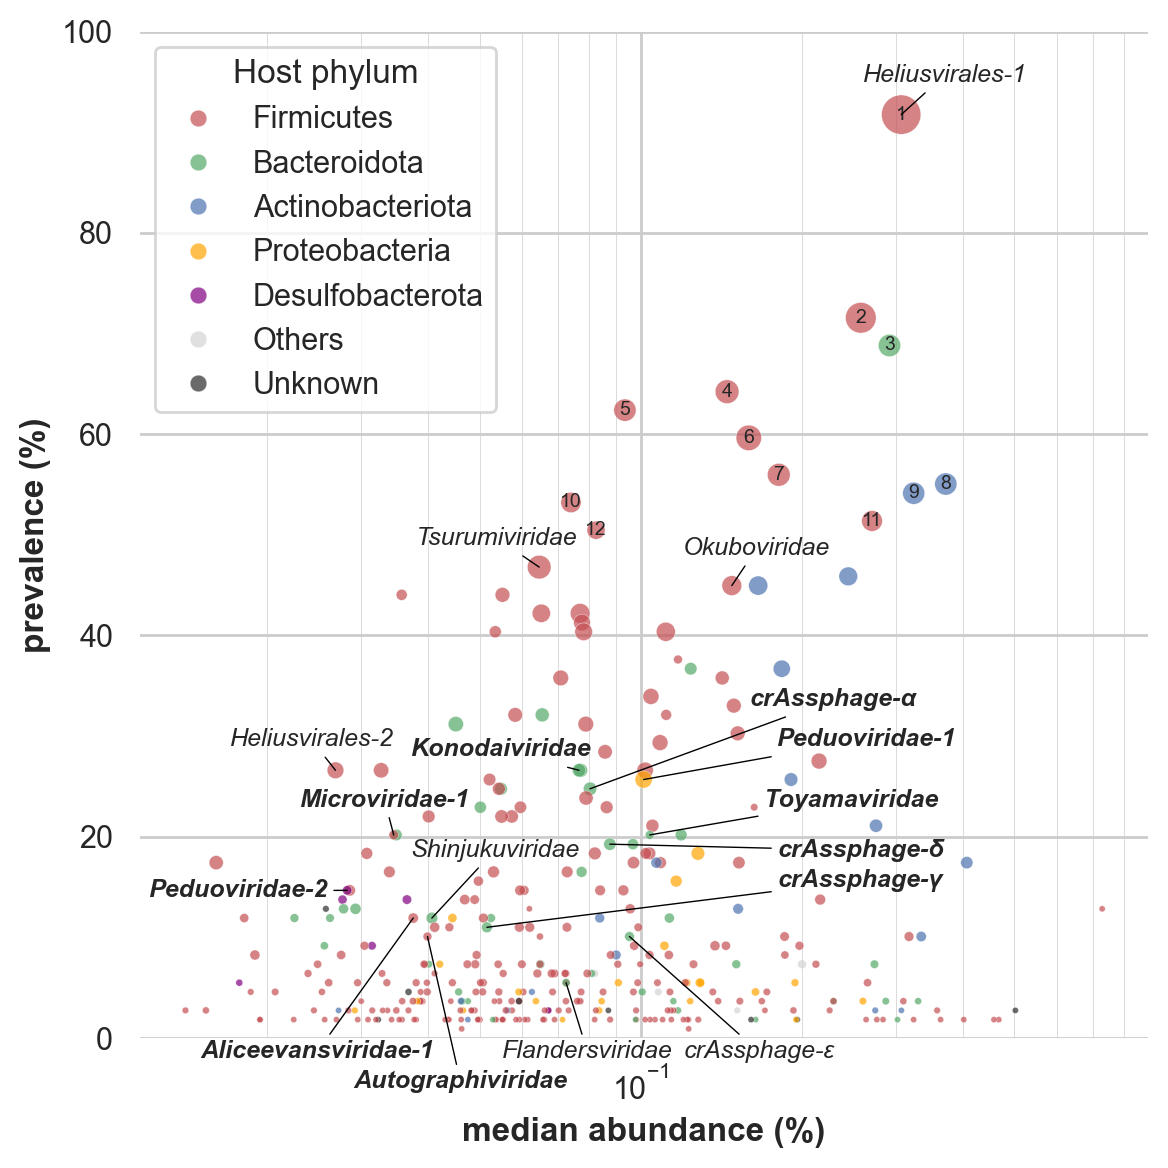

In [3]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6,6), dpi=200)

df1 = df[df.VC_size > 1] # non-singleton VFCs

df1['primary_host_phylum'] = df1['primary_host_phylum'].fillna('Unknown')
df1['primary_host_phylum'] = np.where(df1.primary_host_phylum.isin(['Verrucomicrobiota','Methanobacteriota','Fusobacteriota']), 'Others', df1.primary_host_phylum)

phylum2color = {'Firmicutes': 'r', 'Bacteroidota': 'g', 'Actinobacteriota': 'b', 'Proteobacteria': 'orange', 'Desulfobacterota': 'purple', 'Others': 'lightgray', 'Unknown': '#2b2b2b'}

g = sns.scatterplot(
    data=df1,
    x='median_perc_abun', y='perc_prevalence',
    hue='primary_host_phylum', hue_order=phylum2color,
    size='VC_size',
    palette=phylum2color,
    marker='o',
    sizes=(5, 200), alpha=0.7, ax=ax
)
g.set(xscale="log")
plt.ylim(0,100)

g.xaxis.grid(True, "minor", linewidth=.25)
plt.xlabel('median abundance (%)', weight='bold')
plt.ylabel('prevalence (%)', weight='bold')

legend_handles, _ = ax.get_legend_handles_labels()
ax.legend(legend_handles[1:], phylum2color, title='Host phylum', loc='upper left')

for i in range(1,13):
    ax.annotate(str(i), xy=(df[df.VFC == i].median_perc_abun, df[df.VFC == i].perc_prevalence), ha='center', va='center', fontsize=7)

fs = 9

ax.annotate('Heliusvirales-1', xy=(0.306966, 91.743119), xytext=(0.26, 95), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Heliusvirales-2', xy=(0.026828, 26.605505), xytext=(0.017, 29), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Peduoviridae-1', xy=(0.101191, 25.688073), xytext=(0.18, 29), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Microviridae-1', xy=(0.034479, 20.183486), xytext=(0.023, 23), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Peduoviridae-2', xy=(0.028217, 14.678899), xytext=(0.012, 14), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Aliceevansviridae-1', xy=(0.037504, 11.926606), xytext=(0.015, -2), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Autographiviridae', xy=(0.039875, 10.091743), xytext=(0.029, -5), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-α', xy=(0.080341, 24.770642), xytext=(0.16, 33), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-δ', xy=(0.087480, 19.266055), xytext=(0.18, 18), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-γ', xy=(0.051513, 11.009174), xytext=(0.18, 15), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('crAssphage-ε', xy=(0.095213, 10.091743), xytext=(0.12, -2), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Flandersviridae', xy=(0.072448, 5.504587), xytext=(0.055, -2), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Tsurumiviridae', xy=(0.064535, 46.788991), xytext=(0.038, 49), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Okuboviridae', xy=(0.147958, 44.954128), xytext=(0.12, 48), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Konodaiviridae', xy=(0.076607, 26.605505), xytext=(0.037, 28), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Toyamaviridae', xy=(0.103866, 20.183486), xytext=(0.17, 23), fontsize=fs, fontweight='bold', fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )
ax.annotate('Shinjukuviridae', xy=(0.040646, 11.926606), xytext=(0.037, 18), fontsize=fs, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.5)
            )

sns.despine(left=True, bottom=True)
plt.tight_layout()